In [11]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import geopandas as gpd
from geopandas import GeoSeries
from shapely.geometry import Point, LineString
import os

# Cargar el Excel descargado
df = pd.read_excel("data/listado_iiee.xlsx")

# Revisa qué columnas hay
print(df.columns)

Index(['Código Modular', 'Anexo', 'Nombre de SS.EE.', 'Ubigeo', 'Departamento',
       'Provincia', 'Distrito', 'Código DRE/UGEL', 'DRE / UGEL',
       'Centro Poblado', 'Código Centro Poblado', 'Código Local', 'Dirección',
       'Nivel / Modalidad', 'Gestion / Dependencia', 'Latitud', 'Longitud',
       'Altitud', 'Fuente de coordenadas'],
      dtype='object')


In [17]:
niveles = df['Nivel / Modalidad'].dropna().unique()
for nivel in sorted(niveles):
    print(nivel)

# Convertimos a minúsculas para evitar problemas con mayúsculas/minúsculas
df['nivel_lower'] = df['Nivel / Modalidad'].str.lower()

# Filtros más controlados
filtro_inicial = df['nivel_lower'].str.contains('inicial')
filtro_primaria = df['nivel_lower'].str.contains('primaria')
filtro_secundaria = df['nivel_lower'].str.contains('secundaria')

# Aplicar filtros
df_inicial = df[filtro_inicial]
df_primaria = df[filtro_primaria]
df_secundaria = df[filtro_secundaria]

Básica Alternativa - Avanzado
Básica Alternativa - Inicial e Intermedio
Básica Especial - Inicial
Básica Especial - PRITE
Básica Especial - Primaria
Escuela Superior Pedagógica
Escuela Superior Tecnológica
Inicial - Cuna
Inicial - Cuna Jardín
Inicial - Jardín
Inicial No Escolarizado
Instancia de Apoyo
Primaria
Secundaria
Superior Formación Artística
Superior Pedagógica
Superior Tecnológica
Técnico Productiva - CETPRO


In [19]:
# Revisa cuantas escuelas hay por nivel
print(f"Inicial: {len(df_inicial)} escuelas")
print(f"Primaria: {len(df_primaria)} escuelas")
print(f"Secundaria: {len(df_secundaria)} escuelas")

# Revisa cuantas escuelas hay por nivel dentro de inicial y el tipo de dato
print(df_inicial['Nivel / Modalidad'].value_counts())
print(df_primaria['Nivel / Modalidad'].value_counts())
print(df_secundaria['Nivel / Modalidad'].value_counts())

Inicial: 54839 escuelas
Primaria: 39278 escuelas
Secundaria: 15795 escuelas
Nivel / Modalidad
Inicial - Jardín                             33974
Inicial No Escolarizado                      17624
Inicial - Cuna Jardín                         1900
Básica Alternativa - Inicial e Intermedio      932
Básica Especial - Inicial                      379
Inicial - Cuna                                  30
Name: count, dtype: int64
Nivel / Modalidad
Primaria                      38806
Básica Especial - Primaria      472
Name: count, dtype: int64
Nivel / Modalidad
Secundaria    15795
Name: count, dtype: int64


In [21]:
inicial_count = df_inicial.groupby(['Departamento', 'Provincia', 'Distrito']).size().reset_index(name='n_inicial')
primaria_count = df_primaria.groupby(['Departamento', 'Provincia', 'Distrito']).size().reset_index(name='n_primaria')
secundaria_count = df_secundaria.groupby(['Departamento', 'Provincia', 'Distrito']).size().reset_index(name='n_secundaria')

print(inicial_count.head())
print(primaria_count.head())
print(secundaria_count.head())

  Departamento Provincia  Distrito  n_inicial
0     AMAZONAS     BAGUA  ARAMANGO         54
1     AMAZONAS     BAGUA     BAGUA         33
2     AMAZONAS     BAGUA  COPALLIN         21
3     AMAZONAS     BAGUA  EL PARCO          5
4     AMAZONAS     BAGUA     IMAZA        158
  Departamento Provincia  Distrito  n_primaria
0     AMAZONAS     BAGUA  ARAMANGO          55
1     AMAZONAS     BAGUA     BAGUA          16
2     AMAZONAS     BAGUA  COPALLIN          17
3     AMAZONAS     BAGUA  EL PARCO           2
4     AMAZONAS     BAGUA     IMAZA         158
  Departamento Provincia  Distrito  n_secundaria
0     AMAZONAS     BAGUA  ARAMANGO            12
1     AMAZONAS     BAGUA     BAGUA             8
2     AMAZONAS     BAGUA  COPALLIN             3
3     AMAZONAS     BAGUA  EL PARCO             1
4     AMAZONAS     BAGUA     IMAZA            33


In [23]:
# Cargar shapefile de distritos
gdf_distritos = gpd.read_file("data\shape_file\DISTRITOS.shp")

# Revisa los nombres reales de las columnas en gdf_distritos
print(gdf_distritos.columns)

# Mostrar las primeras filas del GeoDataFrame
print(gdf_distritos.head())

Index(['IDDPTO', 'DEPARTAMEN', 'IDPROV', 'PROVINCIA', 'IDDIST', 'DISTRITO',
       'CAPITAL', 'CODCCPP', 'AREA', 'FUENTE', 'geometry'],
      dtype='object')
  IDDPTO DEPARTAMEN IDPROV    PROVINCIA  IDDIST                DISTRITO  \
0     10    HUANUCO   1009  PUERTO INCA  100902         CODO DEL POZUZO   
1     10    HUANUCO   1009  PUERTO INCA  100904             TOURNAVISTA   
2     25    UCAYALI   2503   PADRE ABAD  250305  ALEXANDER VON HUMBOLDT   
3     25    UCAYALI   2503   PADRE ABAD  250302                 IRAZOLA   
4     25    UCAYALI   2503   PADRE ABAD  250304                 NESHUYA   

                  CAPITAL CODCCPP  AREA FUENTE  \
0         CODO DEL POZUZO    0001     1   INEI   
1             TOURNAVISTA    0001     1   INEI   
2  ALEXANDER VON HUMBOLDT    0001     1   INEI   
3           SAN ALEJANDRO    0001     1   INEI   
4            MONTE ALEGRE    0001     1   INEI   

                                            geometry  
0  POLYGON ((-75.31797 -9.29529, -7

In [59]:
# Unir la geometría de los distritos con los datos de las escuelas por nivel reemplazando NaN por 0
gdf_inicial = gdf_distritos.merge(inicial_count, left_on=['DEPARTAMEN', 'PROVINCIA', 'DISTRITO'], right_on=['Departamento', 'Provincia', 'Distrito'], how='left').fillna({'n_inicial': 0})
gdf_primaria = gdf_distritos.merge(primaria_count, left_on=['DEPARTAMEN', 'PROVINCIA', 'DISTRITO'], right_on=['Departamento', 'Provincia', 'Distrito'], how='left').fillna({'n_primaria': 0})
gdf_secundaria = gdf_distritos.merge(secundaria_count, left_on=['DEPARTAMEN', 'PROVINCIA', 'DISTRITO'], right_on=['Departamento', 'Provincia', 'Distrito'], how='left').fillna({'n_secundaria': 0})

In [61]:
missing = gdf_inicial[gdf_inicial['n_inicial'].isna()]
print(missing[['Departamento', 'Provincia', 'Distrito']])

Empty DataFrame
Columns: [Departamento, Provincia, Distrito]
Index: []


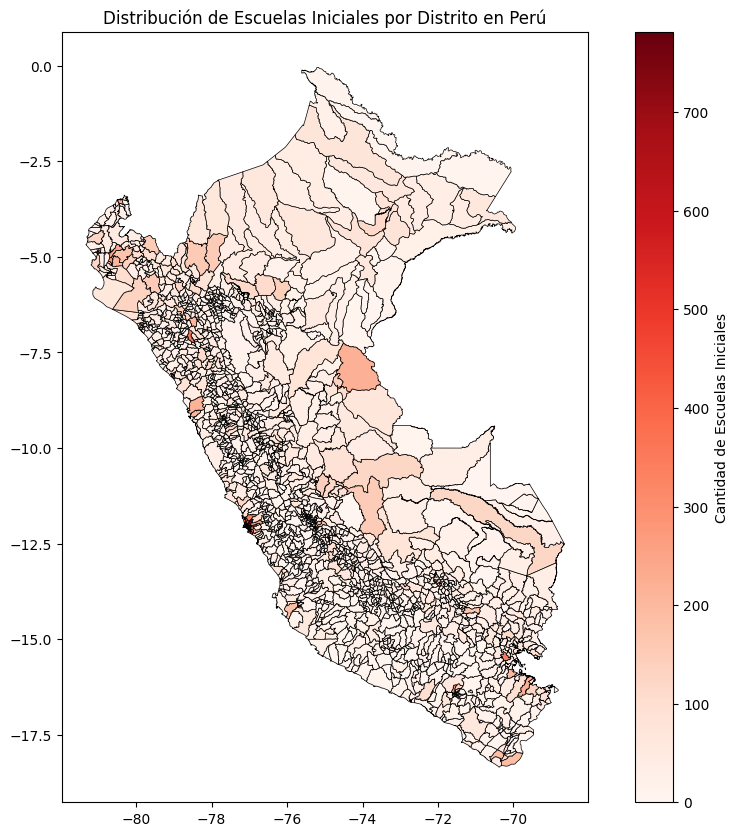

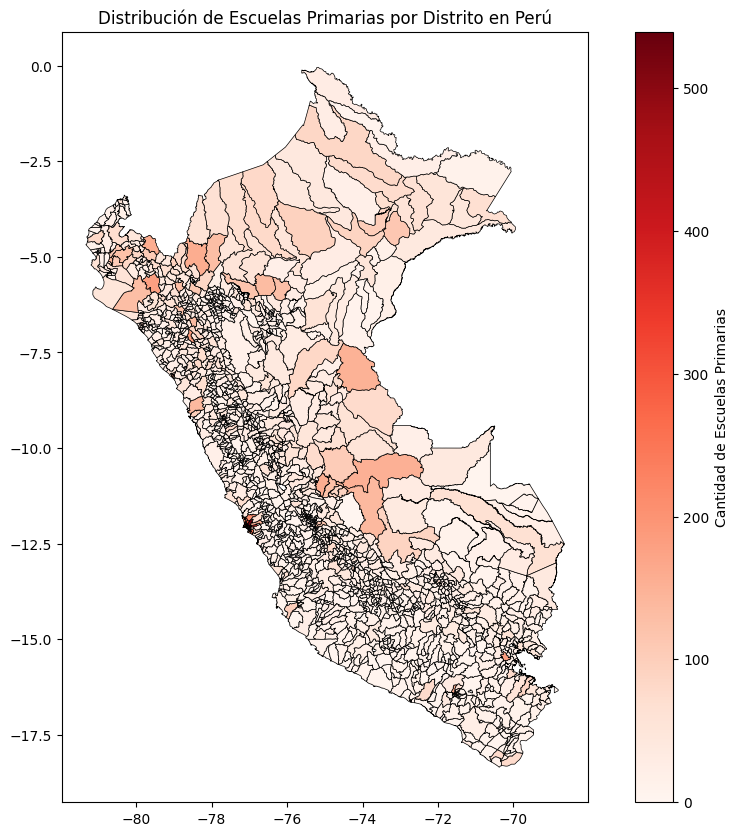

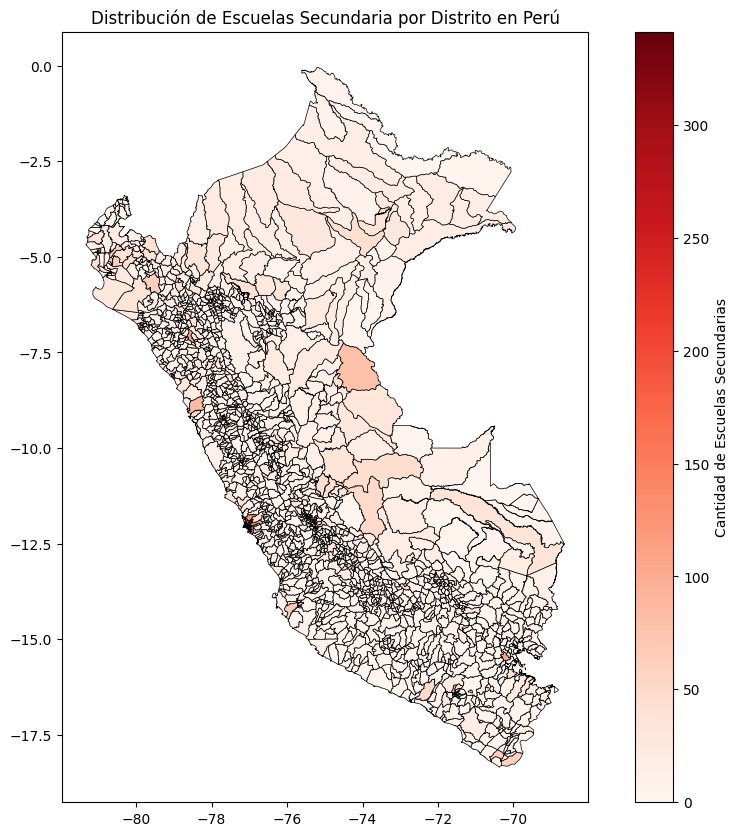

In [91]:
# Crear el mapa para Inicial
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf_inicial.plot(column='n_inicial', cmap='Reds', ax=ax, legend=True,
                 edgecolor='black',
                 legend_kwds={'label': "Cantidad de Escuelas Iniciales"}, 
                 linewidth=0.5)
ax.set_title('Distribución de Escuelas Iniciales por Distrito en Perú')

# Crear el mapa para Primaria
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf_primaria.plot(column='n_primaria', cmap='Reds', ax=ax, legend=True,
                 edgecolor='black',
                 legend_kwds={'label': "Cantidad de Escuelas Primarias"}, 
                 linewidth=0.5)
ax.set_title('Distribución de Escuelas Primarias por Distrito en Perú')

# Crear el mapa para Secundaria
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf_secundaria.plot(column='n_secundaria', cmap='Reds', ax=ax, legend=True,
                 edgecolor='black',
                 legend_kwds={'label': "Cantidad de Escuelas Secundarias"}, 
                 linewidth=0.5)
ax.set_title('Distribución de Escuelas Secundaria por Distrito en Perú')

# Mostrar los mapas
plt.show()
